# Closed Form Black Scholes

To find a closed form solution, we need to impose the most assumptions and work in a simple system

In [3]:
import sys
sys.path.append('..')  # repo root, one level up from notebooks/

import numpy as np
import matplotlib.pyplot as plt
from src.pricing.binomial_tree import multistep
from src.pricing.black_scholes import closed_form_black_scholes
from src.utils.option_properties import Option

In [5]:
opt = Option(
    S_0 = 100,
    K = 100,
    r = 0.05,
    T = 1,
    sigma = 0.2,
    n = 500
)

In [6]:
multistep(opt)

np.float64(10.44658513644654)

In [7]:
closed_form_black_scholes(opt)

np.float64(10.450583572185565)

# Plotting price vs n

we can see that the closed form does not have the convergence property

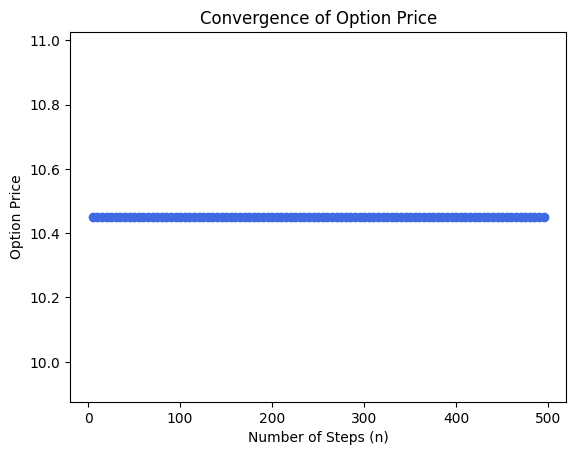

In [8]:
ns = range(5,500,5)
prices = []
for n in ns:
    opt = Option(
        S_0 = 100,
        K = 100,
        r = 0.05,
        T = 1,
        sigma = 0.2,
        n = n
    )
    price = closed_form_black_scholes(opt)
    prices.append(price)

plt.scatter(ns, prices, c = 'royalblue')
plt.xlabel("Number of Steps (n)")
plt.ylabel("Option Price")
plt.title("Convergence of Option Price")
plt.show()

# Price vs Time to Maturity

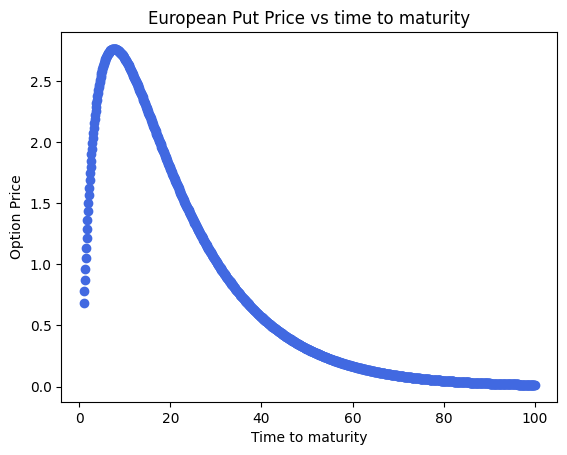

In [9]:
T = np.linspace(1,100,1000)
prices = []
for x in T:
    opt = Option(
        S_0 = 100,
        K = 80,
        r = 0.05,
        T = x,
        sigma = 0.2,
        n = 100
    )
    price = closed_form_black_scholes(opt,option_class="put")
    prices.append(price)

plt.scatter(T, prices, c = 'royalblue')
plt.xlabel("Time to maturity")
plt.ylabel("Option Price")
plt.title("European Put Price vs time to maturity")
plt.show()

# Monte Carlo sims

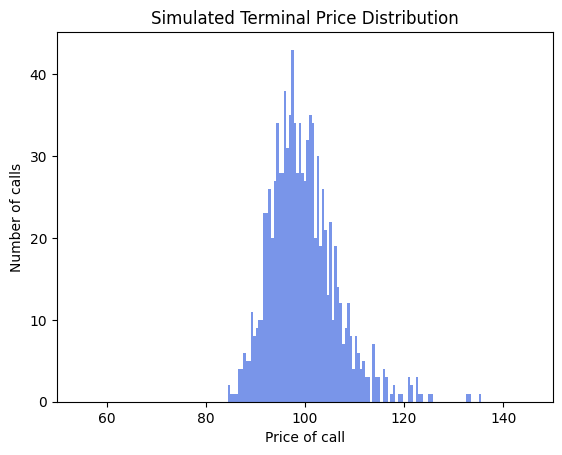

In [28]:
from src.pricing.monte_carlo import closed_form_monte_carlo

n_runs = 1000

call_prices = [closed_form_monte_carlo(opt) for _ in range(n_runs)]

plt.hist(call_prices, bins=100, color='royalblue', alpha=0.7)
plt.xlabel("Price of call")
plt.ylabel("Number of calls")
plt.title("Simulated Terminal Price Distribution")
plt.xlim(50,150)
plt.show()